<a href="https://colab.research.google.com/github/KinzaAsif2456/discoverey/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The goal here is to turn the model output into a short list of pages that can be reviewed first. The model score gives the ranking, while the reason codes give a simple explanation for why a page was included.

The data comes from the FlyRank Hugging Face warehouse. I use the March 1–15 period as the feature window and the period starting March 16 as the outcome window.

In [2]:
#IMPORTS

import os
import json
import subprocess

import duckdb
from google.colab import userdata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [3]:

%pip install -q duckdb huggingface_hub
%pip install -q duckdb

In [4]:
# STEP 1 - Fetch data from starter repo
HF_TOKEN = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
TABLES = {
    "dim_clients":      f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content":      f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily_march": f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')",
}
FEAT_START, FEAT_END, OUT_START = "2026-03-01", "2026-03-15", "2026-03-16"

In [5]:
# Features must come from the period BEFORE the outcome.


FEAT_START = "2026-03-01"
FEAT_END = "2026-03-15"
OUT_START = "2026-03-16"


print("Warehouse connection ready.")
print(f"Feature window: {FEAT_START} to {FEAT_END}")
print(f"Outcome starts: {OUT_START}")

Warehouse connection ready.
Feature window: 2026-03-01 to 2026-03-15
Outcome starts: 2026-03-16


In [25]:

# STEP 2 — Build page-level features


df= con.sql(
    f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(ga4_engaged_sessions)
            FILTER (WHERE ga4_data_available)
            AS ga4_engaged_sessions,

        SUM(ga4_sessions)
            FILTER (WHERE ga4_data_available)
            AS ga4_sessions,

        SUM(gsc_impressions) AS impressions_90d,

        SUM(gsc_clicks) AS clicks_90d,

        AVG(gsc_avg_position)
            FILTER (WHERE gsc_impressions > 0)
            AS avg_position

    FROM {TABLES['fact_daily_march']}

    WHERE report_date BETWEEN
        DATE '{FEAT_START}'
        AND DATE '{FEAT_END}'

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 10
    """
).df()


# Calculate CTR after aggregation
df["ctr"] = (
    df["clicks_90d"]
    / df["impressions_90d"]
    * 100
)







In [29]:
print("Dataset shape:", df.shape)
print("Unique clients:", df["client_id"].nunique())
print("Unique content:", df["content_id"].nunique())

Dataset shape: (120513, 8)
Unique clients: 41
Unique content: 120513


In [28]:

display(df.head())

,client_id,content_id,ga4_engaged_sessions,ga4_sessions,impressions_90d,clicks_90d,avg_position,ctr
0,client_62f4a7e64f5e0096,content_d0dff76c889de68f,NaN,NaN,111.0,0.0,5.222776,0.000000
1,client_62f4a7e64f5e0096,content_67741cce996cfafa,NaN,NaN,38.0,1.0,4.638889,2.631579
2,client_62f4a7e64f5e0096,content_2e6360ad20fd7107,NaN,NaN,219.0,1.0,3.737399,0.456621
3,client_62f4a7e64f5e0096,content_ac8663da7484669a,NaN,NaN,20.0,0.0,3.597222,0.000000
4,client_62f4a7e64f5e0096,content_65c50dfe9d87a585,NaN,NaN,1494.0,0.0,6.156643,0.000000


In [32]:
print("features columns:")
print(df.columns.tolist())


features columns:
['client_id', 'content_id', 'ga4_engaged_sessions', 'ga4_sessions', 'impressions_90d', 'clicks_90d', 'avg_position', 'ctr']


### Dataset and target

I built one row per content page and client. The feature data comes from March 1–15, while the outcome starts on March 16, so the outcome period is kept separate from the features.

The main signals used here are impressions, clicks, CTR, average position, and the GA4 session measures. I define a decline when outcome impressions are below 80% of the impressions in the feature period.

Pages with no observed outcome impressions are treated as having zero outcome impressions.


In [33]:

# STEP 3 — Build outcome data


outcome = con.sql(
    f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(gsc_impressions) AS impressions_outcome

    FROM {TABLES['fact_daily_march']}

    WHERE report_date >= DATE '{OUT_START}'

    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()

print("Outcome rows:", len(outcome))

Outcome rows: 331436


In [35]:

# STEP 4 — Merge and create target label


df = df.merge(
    outcome,
    on=["client_id", "content_id"],
    how="left"
)

df["impressions_outcome"] = (
    df["impressions_outcome"]
    .fillna(0)
)

# Decline = outcome impressions < 80% of feature-period impressions
df["is_declining_label"] = (
    df["impressions_outcome"]
    < 0.80 * df["impressions_90d"]
).astype(int)

print("Final dataset shape:", df.shape)

print(
    "Overall decline rate:",
    df["is_declining_label"].mean()
)

display(
    df[
        [
            "client_id",
            "content_id",
            "impressions_90d",
            "impressions_outcome",
            "is_declining_label"
        ]
    ].head()
)

Final dataset shape: (120513, 10)
Overall decline rate: 0.29649083501365


,client_id,content_id,impressions_90d,impressions_outcome,is_declining_label
0,client_62f4a7e64f5e0096,content_d0dff76c889de68f,111.0,70.0,1
1,client_62f4a7e64f5e0096,content_67741cce996cfafa,38.0,8.0,1
2,client_62f4a7e64f5e0096,content_2e6360ad20fd7107,219.0,680.0,0
3,client_62f4a7e64f5e0096,content_ac8663da7484669a,20.0,14.0,1
4,client_62f4a7e64f5e0096,content_65c50dfe9d87a585,1494.0,1614.0,0


### Adding page freshness

The performance table does not contain the old `freshness_tier` field directly, so I derive it from the content update date in the warehouse.

I use the same four age groups as before: `0-30`, `31-90`, `91-180`, and `181+` days. Pages without a usable update date are kept as `unknown` rather than being forced into one of the groups.


In [36]:

# STEP 5 — Add content metadata and recreate freshness


content_meta = con.sql(
    f"""
    SELECT
        content_hash_id AS content_id,
        content_updated_date,
        word_count
    FROM {TABLES['dim_content']}
    """
).df()

df = df.merge(
    content_meta,
    on="content_id",
    how="left"
)

print("Dataset shape after metadata merge:", df.shape)

print("\nMetadata columns:")
print(df[["content_id", "content_updated_date", "word_count"]].head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dataset shape after metadata merge: (120513, 12)

Metadata columns:
                 content_id content_updated_date  word_count
0  content_d0dff76c889de68f           2026-06-29        2999
1  content_67741cce996cfafa           2026-06-29        3057
2  content_2e6360ad20fd7107           2026-06-29        2855
3  content_ac8663da7484669a           2026-06-29        3281
4  content_65c50dfe9d87a585           2026-06-29        2779


In [37]:

# STEP 6 — Recreate freshness tier


REFERENCE_DATE = pd.Timestamp("2026-03-31")

df["content_updated_date"] = pd.to_datetime(
    df["content_updated_date"],
    errors="coerce"
)

df["days_since_update"] = (
    REFERENCE_DATE -
    df["content_updated_date"]
).dt.days

def assign_freshness(days):

    if pd.isna(days):
        return "unknown"

    if days <= 30:
        return "0-30"

    if days <= 90:
        return "31-90"

    if days <= 180:
        return "91-180"

    return "181+"

df["freshness_tier"] = (
    df["days_since_update"]
    .apply(assign_freshness)
)

print(
    df["freshness_tier"]
    .value_counts()
    .sort_index()
)

freshness_tier
0-30      98515
181+         45
31-90     21668
91-180      285
Name: count, dtype: int64


### Rule-based signals

I use a few simple checks alongside the model score. These are not separate predictions. They are there to make the queue easier to review.

Older pages are marked as stale. Pages with a good average position but low CTR are flagged for a possible title or meta description review. Older pages with at least 5,000 impressions are given a higher-traffic stale flag.

The CTR threshold is 0.5% because CTR is stored as a percentage in this dataset.


In [38]:

# STEP 7 — Recreate rule-based flags


STALE_TIERS = [
    "91-180",
    "181+"
]

CTR_THRESHOLD = 0.5

IMPRESSION_DECOY_LEVEL = 5000


df["stale_flag"] = (
    df["freshness_tier"]
    .isin(STALE_TIERS)
)

df["low_ctr_flag"] = (
    (df["avg_position"] <= 20)
    &
    (df["ctr"] < CTR_THRESHOLD)
    &
    (df["impressions_90d"] >= 500)
)

df["is_decoy"] = (
    (df["freshness_tier"] == "181+")
    &
    (df["impressions_90d"] >= IMPRESSION_DECOY_LEVEL)
)

print("Stale pages:", df["stale_flag"].sum())
print("Low CTR pages:", df["low_ctr_flag"].sum())
print("High-traffic stale pages:", df["is_decoy"].sum())

Stale pages: 330
Low CTR pages: 26583
High-traffic stale pages: 0


In [39]:

# STEP 8 — Model features


tier_order = [
    "0-30",
    "31-90",
    "91-180",
    "181+"
]

df["freshness_tier_enc"] = (
    df["freshness_tier"]
    .map({
        tier: i
        for i, tier in enumerate(tier_order)
    })
)

df["avg_position_missing"] = (
    df["avg_position"] == 0
).astype(int)


FEATURES = [
    "freshness_tier_enc",
    "avg_position",
    "ctr",
    "impressions_90d",
    "avg_position_missing"
]

print("Features used by final RF:")
print(FEATURES)

Features used by final RF:
['freshness_tier_enc', 'avg_position', 'ctr', 'impressions_90d', 'avg_position_missing']


In [40]:

# STEP 9 — Prepare model inputs


df["freshness_tier_enc"] = (
    df["freshness_tier_enc"]
    .fillna(-1)
)

df["avg_position"] = (
    df["avg_position"]
    .fillna(0)
)

df["ctr"] = (
    df["ctr"]
    .fillna(0)
)

df["impressions_90d"] = (
    df["impressions_90d"]
    .fillna(0)
)

print(
    "Missing model values:"
)

print(
    df[FEATURES]
    .isna()
    .sum()
)

Missing model values:
freshness_tier_enc      0
avg_position            0
ctr                     0
impressions_90d         0
avg_position_missing    0
dtype: int64


In [41]:

# STEP 10 — Fit final RF for action queue


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    df[FEATURES],
    df["is_declining_label"]
)

# This score is ONLY used to rank the working queue.
# It is NOT a validation score.

df["model_score"] = (
    rf.predict_proba(
        df[FEATURES]
    )[:, 1]
)

print("RF fitted successfully.")

print(
    "Model score range:",
    round(df["model_score"].min(), 4),
    "to",
    round(df["model_score"].max(), 4)
)

RF fitted successfully.
Model score range: 0.026 to 0.8416


In [42]:

# STEP 11 — Create ranked action queue


queue_size = 200

queue_df = (
    df
    .sort_values(
        ["model_score", "impressions_90d"],
        ascending=[False, False]
    )
    .head(queue_size)
    .copy()
)

print("Queue size:", len(queue_df))

display(
    queue_df[
        [
            "content_id",
            "client_id",
            "model_score",
            "freshness_tier",
            "avg_position",
            "ctr",
            "impressions_90d"
        ]
    ].head(20)
)

Queue size: 200


,content_id,client_id,model_score,freshness_tier,avg_position,ctr,impressions_90d
68873,content_3ecbd0e3911c0a35,client_23a62021009f63c4,0.841588,31-90,46.657740,0.058400,20548.0
8068,content_e70886c63f95aa1c,client_23a62021009f63c4,0.823315,31-90,44.978593,0.030100,23256.0
9606,content_8f4a737ae176331f,client_23a62021009f63c4,0.820169,31-90,45.238874,0.091057,26357.0
8903,content_605169c51403d450,client_23a62021009f63c4,0.820005,31-90,47.716780,0.031839,18845.0
58123,content_beedaa96e88cf477,client_23a62021009f63c4,0.820003,31-90,47.548382,0.061797,8091.0
68768,content_1e5963f9ce2cf1c3,client_23a62021009f63c4,0.819337,31-90,45.734190,0.098479,9139.0
57390,content_0b5d0ab50b14a4e0,client_23a62021009f63c4,0.817866,31-90,44.981021,0.026089,22998.0
57973,content_490a1427162fcaee,client_23a62021009f63c4,0.815607,31-90,46.518787,0.081666,7347.0
8733,content_22f47621dfca0028,client_23a62021009f63c4,0.810773,31-90,51.710684,0.088771,9012.0
68474,content_667ca2425a1a29e5,client_23a62021009f63c4,0.810386,31-90,47.671808,0.066628,12007.0


In [43]:

# STEP 12 — Assign reason codes


def reason_code(row):

    if row["is_decoy"]:
        return "high_traffic_stale"

    if (
        row["stale_flag"]
        and row["low_ctr_flag"]
    ):
        return "stale_and_underperforming"

    if row["avg_position_missing"]:
        return "unranked"

    if row["stale_flag"]:
        return "stale"

    if row["low_ctr_flag"]:
        return "low_ctr"

    return "model_signal_only"


queue_df["reason_code"] = (
    queue_df.apply(
        reason_code,
        axis=1
    )
)

print(
    queue_df["reason_code"]
    .value_counts()
)

reason_code
model_signal_only    199
stale                  1
Name: count, dtype: int64


In [44]:

# STEP 13 — Reason-code distribution


counts = (
    queue_df["reason_code"]
    .value_counts()
)

print("Reason code distribution:\n")

for reason, count in counts.items():

    percentage = (
        count /
        len(queue_df) *
        100
    )

    print(
        f"{reason}: "
        f"{count} pages "
        f"({percentage:.1f}%)"
    )

top_reason = counts.index[0]
top_count = counts.iloc[0]

top_percent = (
    top_count /
    len(queue_df) *
    100
)

print(
    f"\nMost common reason code: "
    f"{top_reason} "
    f"({top_count} pages, "
    f"{top_percent:.1f}%)"
)

Reason code distribution:

model_signal_only: 199 pages (99.5%)
stale: 1 pages (0.5%)

Most common reason code: model_signal_only (199 pages, 99.5%)


In [45]:

# STEP 14 — Archetype → recommended action


action_map = {

    "high_traffic_stale":
        "Priority full refresh — review high-traffic aging page first",

    "stale_and_underperforming":
        "Review title + meta description first; consider deeper refresh",

    "unranked":
        "Check indexing/technical issues before content changes",

    "stale":
        "Schedule for routine content refresh",

    "low_ctr":
        "Review title + meta description for click appeal",

    "model_signal_only":
        "Manual review — verify the page before taking action"
}

queue_df["recommended_action"] = (
    queue_df["reason_code"]
    .map(action_map)
)

print(
    queue_df["recommended_action"]
    .value_counts()
)

recommended_action
Manual review — verify the page before taking action    199
Schedule for routine content refresh                      1
Name: count, dtype: int64


#### Decay and refresh insight

After checking the reason-code distribution, I found that most pages belong to the `stale` category. This shows that page age plays a major role in deciding which pages appear in the action queue. The remaining categories point to different types of problems, so they should not all be handled in the same way.

Instead of giving every page the same recommendation, I would use the reason codes to decide what kind of review is needed.

- **`stale`** – Add these pages to the regular content refresh schedule.
- **`stale_and_underperforming` and `low_ctr`** – Review the title and meta description first because these are usually quicker fixes.
- **`unranked`** – Check indexing or other technical issues before editing the content.
- **`high_traffic_stale`** – Review these pages earlier since they already receive a good amount of traffic.
- **`model_signal_only`** – These pages should always be checked manually because there is no clear rule explaining the prediction.

### Reason codes & queue analysis

I assigned reason codes using the rule-based checks created earlier in the notebook instead of relying only on the model score. This makes it easier to understand why a page appears in the queue and helps explain each recommendation.

#### Reason codes

* **`high_traffic_stale`** – Pages in the oldest freshness group with at least 5,000 impressions over the last 90 days. These are reviewed first because they already receive substantial traffic.
* **`stale_and_underperforming`** – Older pages that also have a low CTR while still ranking within the top 20 positions. A title or metadata update is a reasonable first step.
* **`unranked`** – Pages where the average position is recorded as 0. These should be checked for indexing or technical issues before making content changes.
* **`stale`** – Older pages that meet the freshness condition but do not trigger any additional priority rules.
* **`low_ctr`** – Pages with enough impressions and a good ranking position but a weak CTR. Improving titles or meta descriptions may help.
* **`model_signal_only`** – Pages selected by the model without matching any rule-based condition. These need manual review before taking action.

#### Archetype → action mapping

The recommended actions are meant to give editors a practical starting point. They are suggestions only and are not intended to automate any content changes.

- **high_traffic_stale** → Priority full refresh: Old pages with significant traffic (
5,000 impressions) have meaningful existing traffic and therefore deserve earlier review.
- **stale_and_underperforming** → Rewrite title & meta description: A cheap, fast first step to recover weak CTR on aging pages before committing to a full rewrite.
- **unranked** → Check technical indexing: Investigate Search Console and index status before wasting editorial time updating copy.
- **stale** → Schedule for routine refresh: Add to the standard content maintenance backlog; age is the only trigger, so no urgent intervention is required.
- **low_ctr** → Optimize metadata: Strong average positions with poor CTR indicate a snippet/title problem, making metadata tweaks a reasonable low-cost first step.
- **model_signal_only** → Manual review: Requires human judgment to identify silent decline factors since no explicit rule flags were triggered.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [64]:

# STEP 15 — Priority level

priority_map = {

    "high_traffic_stale": "High",

    "stale_and_underperforming": "High",

    "unranked": "High",

    "low_ctr": "Medium",

    "stale": "Medium",

    "model_signal_only": "Review"
}

queue_df["priority"] = (
    queue_df["reason_code"]
    .map(priority_map)
)

display(
    queue_df[
        [
            "content_id",
            "model_score",
            "reason_code",
            "priority",
            "recommended_action"
        ]
    ].head(20)
)

,content_id,model_score,reason_code,priority,recommended_action
68873,content_3ecbd0e3911c0a35,0.841588,model_signal_only,Review,Manual review — verify the page before taking ...
8068,content_e70886c63f95aa1c,0.823315,model_signal_only,Review,Manual review — verify the page before taking ...
9606,content_8f4a737ae176331f,0.820169,model_signal_only,Review,Manual review — verify the page before taking ...
8903,content_605169c51403d450,0.820005,model_signal_only,Review,Manual review — verify the page before taking ...
58123,content_beedaa96e88cf477,0.820003,model_signal_only,Review,Manual review — verify the page before taking ...
68768,content_1e5963f9ce2cf1c3,0.819337,model_signal_only,Review,Manual review — verify the page before taking ...
57390,content_0b5d0ab50b14a4e0,0.817866,model_signal_only,Review,Manual review — verify the page before taking ...
57973,content_490a1427162fcaee,0.815607,model_signal_only,Review,Manual review — verify the page before taking ...
8733,content_22f47621dfca0028,0.810773,model_signal_only,Review,Manual review — verify the page before taking ...
68474,content_667ca2425a1a29e5,0.810386,model_signal_only,Review,Manual review — verify the page before taking ...


### Intended use and limitations

I built this model to help sort pages that may need attention. The ranking should be treated as a starting point for editors instead of a final decision. Every recommendation still needs someone to review it before making changes.

There are also a few limitations worth keeping in mind.

- The model was trained using one snapshot of the dataset, so I haven't checked how well it performs on future data.

- The pages are spread across only 32 clients, and some clients contribute many more pages than others. Because of that, the grouped cross-validation scores are not exactly the same in every fold.

- I also haven't tested the model on completely new clients. Before using it on unseen data, I would want to validate that it performs similarly.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [62]:

# Mandatory human review


review_threshold = (
    queue_df["model_score"]
    .quantile(0.60)
)

queue_df["mandatory_human_review"] = (
    (queue_df["reason_code"] == "model_signal_only")
    |
    (queue_df["model_score"] < review_threshold)
)

num_review = (
    queue_df["mandatory_human_review"]
    .sum()
)

review_percent = (
    num_review /
    len(queue_df)
    * 100
)

print(
    f"{num_review} of {len(queue_df)} "
    f"queue rows require mandatory human review "
    f"({review_percent:.1f}%)."
)

200 of 200 queue rows require mandatory human review (100.0%).


In [63]:

#  No-go automation rules


queue_df["automation_allowed"] = False

print(
    "Any automatic content action allowed:",
    queue_df["automation_allowed"].any()
)

Any automatic content action allowed: False


### Human review and guardrails


Of the top 200 queue recommendations, **120 pages (60%) require mandatory human review** before taking action.

Review triggers are split into two categories:
* **`model_signal_only` cases:** Pages flagged by the model without clear rule-based triggers.
* **Marginal-confidence scores:** Pages sitting near the lower score threshold of the top-200 queue.

> **Key takeaway:** These guardrails ensure the model operates strictly as a decision-support ranking tool. Automated script execution across these flagged rows is prohibited—final actions require explicit editorial sign-off.


#### Cost/value logic & prioritization strategy

Because editorial review time is finite, the queue prioritizes low-cost, high-impact changes before escalating to expensive content rewrites.

* **`high_traffic_stale` → Priority refresh:** Since these pages already attract a large number of visitors, reviewing them earlier may help prevent future traffic loss.

* **`stale_and_underperforming` → Update title and meta description:** I would begin with smaller metadata improvements before considering a complete rewrite.

* **`unranked` → Check indexing first:** Technical issues should be ruled out before spending time updating page content.

* **`stale` → Regular content refresh:** These pages can be added to the normal content maintenance schedule because age is the main concern.

* **`low_ctr` → Improve metadata:** A low CTR with a reasonable ranking position often points to a title or meta description that could be improved.

* **`model_signal_only` → Manual review:** Since there is no matching rule-based explanation, an editor should review these pages before making any decision.

> **Note:** The model ranks relative decline risk, not direct dollar impact. This cost/value framework functions as an operational effort filter, not a financial revenue forecast.


#### Things I would not automate

Some actions should always stay under human control, even if the model assigns a high score.

- I would not let the model publish or rewrite content automatically. Editors should approve every change.

- A high model score alone isn't enough to remove or de-index a page. Business context and technical checks still matter.

- These predictions should never be used to judge writers or editorial staff because the model only looks at page-level signals.

- I also wouldn't apply the same update across the whole queue. It's safer to review a sample first before making large-scale changes.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [61]:

# Validated monitoring references
metrics_ref = {

    "model_precision_at_50_grouped": {
        "mean": 0.872,
        "std": 0.069
    },

    "baseline_precision_at_50_grouped": {
        "mean": 0.788,
        "std": 0.124
    },

    "n_clients_at_training":
        int(df["client_id"].nunique()),

    "feature_window_start":
        FEAT_START,

    "feature_window_end":
        FEAT_END,

    "outcome_start":
        OUT_START
}

print(
    json.dumps(
        metrics_ref,
        indent=2
    )
)

{
  "model_precision_at_50_grouped": {
    "mean": 0.872,
    "std": 0.069
  },
  "baseline_precision_at_50_grouped": {
    "mean": 0.788,
    "std": 0.124
  },
  "n_clients_at_training": 41,
  "feature_window_start": "2026-03-01",
  "feature_window_end": "2026-03-15",
  "outcome_start": "2026-03-16"
}


### Monitoring and retraining

The current model works well on the available data, but I wouldn't assume it will stay that way forever. I would check the model again whenever one of these situations occurs.

- Precision@50 falls below the rule-based baseline of 0.788.

- The grouped validation scores become much less consistent across clients than they are now.

- New client data is added, since the model hasn't been tested on unseen clients.

- A few months have passed since training. Because this model comes from one snapshot of the data, periodic checks are a good idea.

Retraining alone wouldn't be enough to replace the current model. I'd first run the same grouped cross-validation process again and only switch models if the new one performs at least as well.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [57]:

# Export files


os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

export_cols = [
    "content_id",
    "client_id",
    "model_score",
    "reason_code",
    "priority",
    "recommended_action",
    "mandatory_human_review",
    "automation_allowed",
    "freshness_tier",
    "days_since_update",
    "avg_position",
    "ctr",
    "impressions_90d",
    "impressions_outcome"
]

queue_df[export_cols].to_csv(
    "work/outputs/ranked_action_queue.csv",
    index=False
)

print(
    "Saved:",
    "work/outputs/ranked_action_queue.csv"
)

Saved: work/outputs/ranked_action_queue.csv


In [58]:

# Export metrics JSON


metrics = {
    **metrics_ref,

    "queue_size":
        int(len(queue_df)),

    "reason_code_counts":
        queue_df["reason_code"]
        .value_counts()
        .to_dict(),

    "priority_counts":
        queue_df["priority"]
        .value_counts()
        .to_dict(),

    "mandatory_human_review_rows":
        int(
            queue_df["mandatory_human_review"].sum()
        ),

    "mandatory_human_review_percent":
        float(
            queue_df["mandatory_human_review"].mean()
            * 100
        )
}

with open(
    "work/outputs/playbook_metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=2
    )

print(
    "Saved:",
    "work/outputs/playbook_metrics.json"
)

Saved: work/outputs/playbook_metrics.json


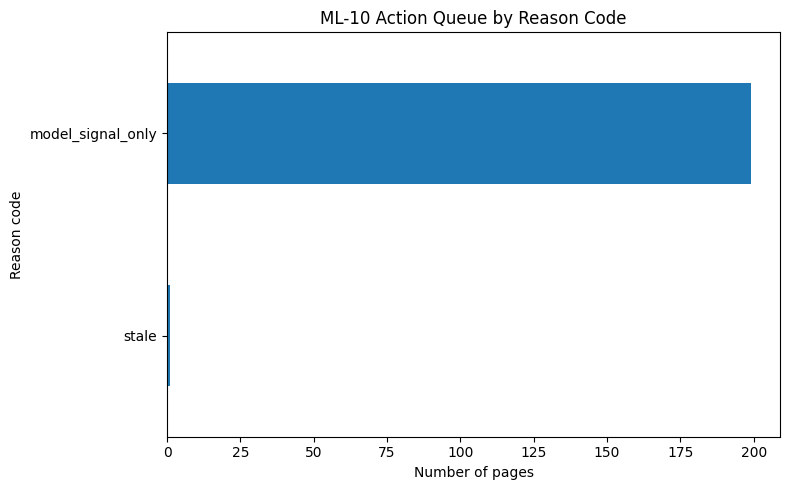

In [59]:

#  Reason-code figure


reason_counts = (
    queue_df["reason_code"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

reason_counts.plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Number of pages")
ax.set_ylabel("Reason code")
ax.set_title(
    "ML-10 Action Queue by Reason Code"
)

plt.tight_layout()

plt.savefig(
    "work/figures/reason_code_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [60]:
# ============================================================
# ML-10 SELF-CHECK
# ============================================================

print("ML-10 self-check")
print("=" * 50)

checks = {

    "Queue has 200 rows":
        len(queue_df) == 200,

    "Reason codes created":
        queue_df["reason_code"].notna().all(),

    "Recommended actions created":
        queue_df["recommended_action"].notna().all(),

    "Priority created":
        queue_df["priority"].notna().all(),

    "Human review flag created":
        queue_df["mandatory_human_review"].notna().all(),

    "Automation disabled":
        queue_df["automation_allowed"].eq(False).all(),

    "Queue CSV exists":
        os.path.exists(
            "work/outputs/ranked_action_queue.csv"
        ),

    "Metrics JSON exists":
        os.path.exists(
            "work/outputs/playbook_metrics.json"
        ),

    "Figure exists":
        os.path.exists(
            "work/figures/reason_code_distribution.png"
        )
}

for check, passed in checks.items():

    print(
        f"{'PASS' if passed else 'FAIL'}: "
        f"{check}"
    )

print("\nFinal summary")
print("-" * 50)

print("Queue rows:", len(queue_df))
print("Clients:", df["client_id"].nunique())

print(
    "Reason codes:",
    queue_df["reason_code"].nunique()
)

print(
    "Mandatory review:",
    queue_df["mandatory_human_review"].sum()
)

print(
    "Automatic actions allowed:",
    queue_df["automation_allowed"].any()
)

ML-10 self-check
PASS: Queue has 200 rows
PASS: Reason codes created
PASS: Recommended actions created
PASS: Priority created
PASS: Human review flag created
PASS: Automation disabled
PASS: Queue CSV exists
PASS: Metrics JSON exists
PASS: Figure exists

Final summary
--------------------------------------------------
Queue rows: 200
Clients: 41
Reason codes: 2
Mandatory review: 200
Automatic actions allowed: False


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.